# Independent Component Analysis (ICA)

## The Cocktail Party Problem

Suppose $n$ independent sources $s_1(t), \ldots, s_n(t)$ are mixed by an unknown $n \times n$ matrix $A$:
$$x(t) = A s(t)$$

**Independent Component Analysis** (ICA) aims to recover the sources $s$ from the observations $x$, knowing only that the $s_i$ are statistically independent and non-Gaussian.

## Why Gaussian is Special

If all $s_i$ were Gaussian, any rotation of the unmixed signal would also produce Gaussian components, making the sources unidentifiable. Non-Gaussianity is the key: it breaks the symmetry and allows unique recovery (up to permutation and sign).

## FastICA Algorithm

The **FastICA** algorithm by Hyvärinen & Oja (1997) maximizes non-Gaussianity via a negentropy proxy. Given a contrast function $G$ (e.g., $G(u) = \log \cosh(u)$ or $G(u) = -e^{-u^2/2}$), the update rule for one component $w$ is:
$$w \leftarrow E[x G'(w^T x)] - E[G''(w^T x)] w, \quad w \leftarrow w / \|w\|$$

Multiple components are extracted by **deflation** (projecting out already-found directions).

## Geometric Picture

After whitening (making $x$ have identity covariance), the ICA problem reduces to finding the rotation $R$ such that $R^T x$ has maximally non-Gaussian components. In 2D, this is simply finding the angle $\theta$ that aligns the axes of the joint distribution with the independent source axes.

### Environment setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

### Generate independent non-Gaussian sources

We create two independent sources:
- $s_1$: sinusoidal — bounded, non-Gaussian
- $s_2$: sawtooth (uniform distribution) — also non-Gaussian

The mixing matrix $A$ is a rotation by angle $\varphi$ followed by a stretch.

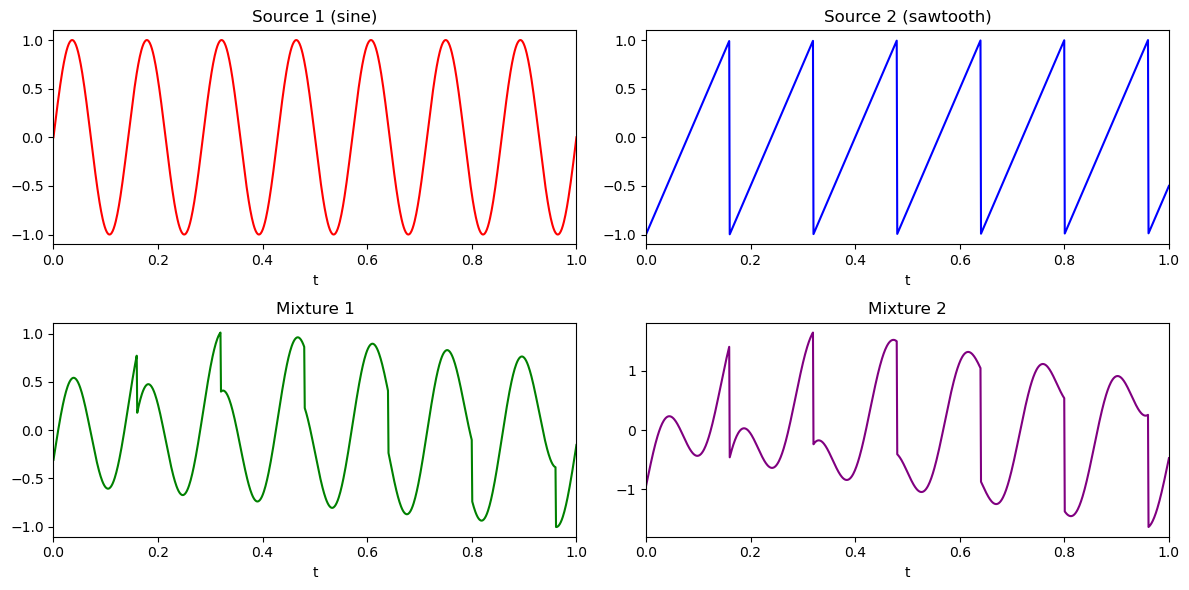

In [2]:
n = 1000  # samples
t = np.linspace(0, 1, n)

# Independent sources
s1 = np.sin(2 * np.pi * 7 * t)              # sinusoidal
s2 = 2 * (t * 6.25 % 1) - 1                 # sawtooth
S = np.vstack([s1, s2])  # shape (2, n)

# Mixing matrix: rotation by phi + shear
phi = np.pi * 0.25
psi = np.pi * 0.40
A = np.array([[np.cos(phi), np.cos(psi)],
              [np.sin(phi), np.sin(psi)]])
X = A @ S  # mixed observations

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, sig, title, c in zip(
    axes.ravel(),
    [s1, s2, X[0], X[1]],
    ['Source 1 (sine)', 'Source 2 (sawtooth)', 'Mixture 1', 'Mixture 2'],
    ['red','blue','green','purple']):
    ax.plot(t, sig, color=c, lw=1.5)
    ax.set_title(title); ax.set_xlabel('t'); ax.set_xlim(0,1)
plt.tight_layout(); plt.savefig('ica_sources.png', dpi=100, bbox_inches='tight'); plt.show()

### Joint distribution: source vs. mixture

Before mixing, the joint distribution $(s_1, s_2)$ is **axis-aligned** and has a characteristic non-Gaussian shape (the axes of independence are visible). After mixing, the distribution is rotated/sheared and looks different. ICA aims to find the rotation that restores axis-alignment.

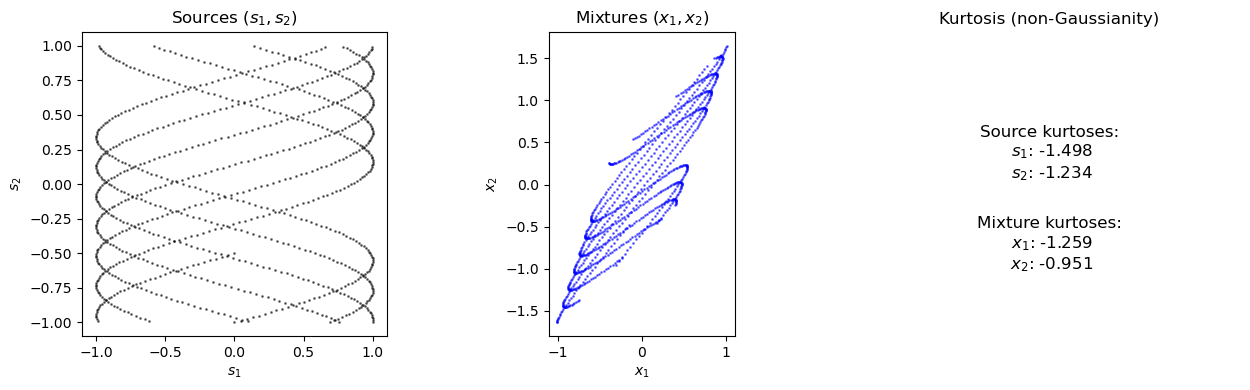

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].plot(s1, s2, 'k.', ms=2, alpha=0.5)
axes[0].set_title('Sources $(s_1, s_2)$'); axes[0].set_xlabel('$s_1$'); axes[0].set_ylabel('$s_2$')
axes[0].set_aspect('equal')

axes[1].plot(X[0], X[1], 'b.', ms=2, alpha=0.5)
axes[1].set_title('Mixtures $(x_1, x_2)$'); axes[1].set_xlabel('$x_1$'); axes[1].set_ylabel('$x_2$')
axes[1].set_aspect('equal')

# Scatter with kurtosis info
kurtosis = lambda v: np.mean((v - v.mean())**4) / np.std(v)**4 - 3
axes[2].text(0.5, 0.6, f'Source kurtoses:\n $s_1$: {kurtosis(s1):.3f}\n $s_2$: {kurtosis(s2):.3f}',
             ha='center', va='center', fontsize=12, transform=axes[2].transAxes)
axes[2].text(0.5, 0.3, f'Mixture kurtoses:\n $x_1$: {kurtosis(X[0]):.3f}\n $x_2$: {kurtosis(X[1]):.3f}',
             ha='center', va='center', fontsize=12, transform=axes[2].transAxes)
axes[2].set_title('Kurtosis (non-Gaussianity)'); axes[2].axis('off')

plt.tight_layout(); plt.savefig('ica_scatter.png', dpi=100, bbox_inches='tight'); plt.show()

### Step 1: Whitening

Before applying ICA, we **whiten** the data (spherize it) so that the covariance becomes the identity matrix:
$$\tilde{X} = \Lambda^{-1/2} V^T X$$

where $V \Lambda V^T = \text{Cov}(X)$ is the eigendecomposition. After whitening, the ICA problem reduces to finding a rotation.

Cov(X_white) ≈
[[1. 0.]
 [0. 1.]]


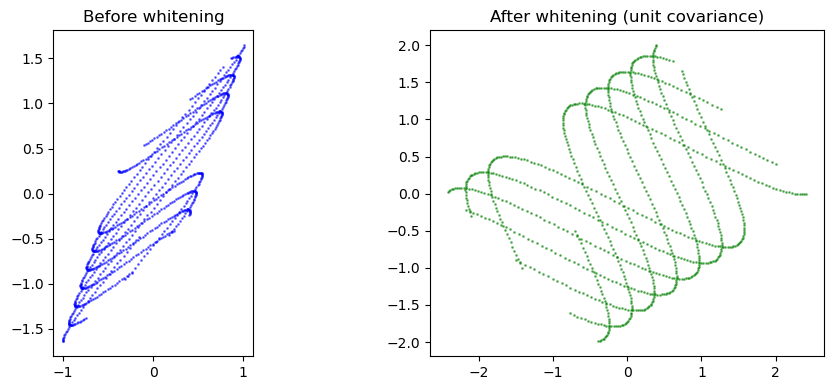

In [4]:
def whiten(X):
    """Whiten data: return X_white and the whitening matrix W_mat."""
    Cov = X @ X.T / X.shape[1]
    eigenvalues, V = np.linalg.eigh(Cov)
    W_mat = np.diag(1.0 / np.sqrt(eigenvalues + 1e-10)) @ V.T
    return W_mat @ X, W_mat

X_white, W_mat = whiten(X)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(X[0], X[1], 'b.', ms=2, alpha=0.5)
axes[0].set_title('Before whitening'); axes[0].set_aspect('equal')
axes[1].plot(X_white[0], X_white[1], 'g.', ms=2, alpha=0.5)
axes[1].set_title('After whitening (unit covariance)'); axes[1].set_aspect('equal')
print(f'Cov(X_white) ≈\n{np.round(X_white @ X_white.T / n, 3)}')
plt.tight_layout(); plt.savefig('ica_whitening.png', dpi=100, bbox_inches='tight'); plt.show()

### Step 2: FastICA rotation

We implement FastICA using the $\tanh$ contrast function $G'(u) = \tanh(u)$. For whitened data, we search for a unit vector $w$ such that the projection $y = w^T \tilde{X}$ has maximal non-Gaussianity:
$$w \leftarrow \frac{1}{n} \tilde{X} \tanh(w^T \tilde{X})^T - \overline{1-\tanh^2(w^T \tilde{X})} \cdot w, \quad w \leftarrow w/\|w\|$$

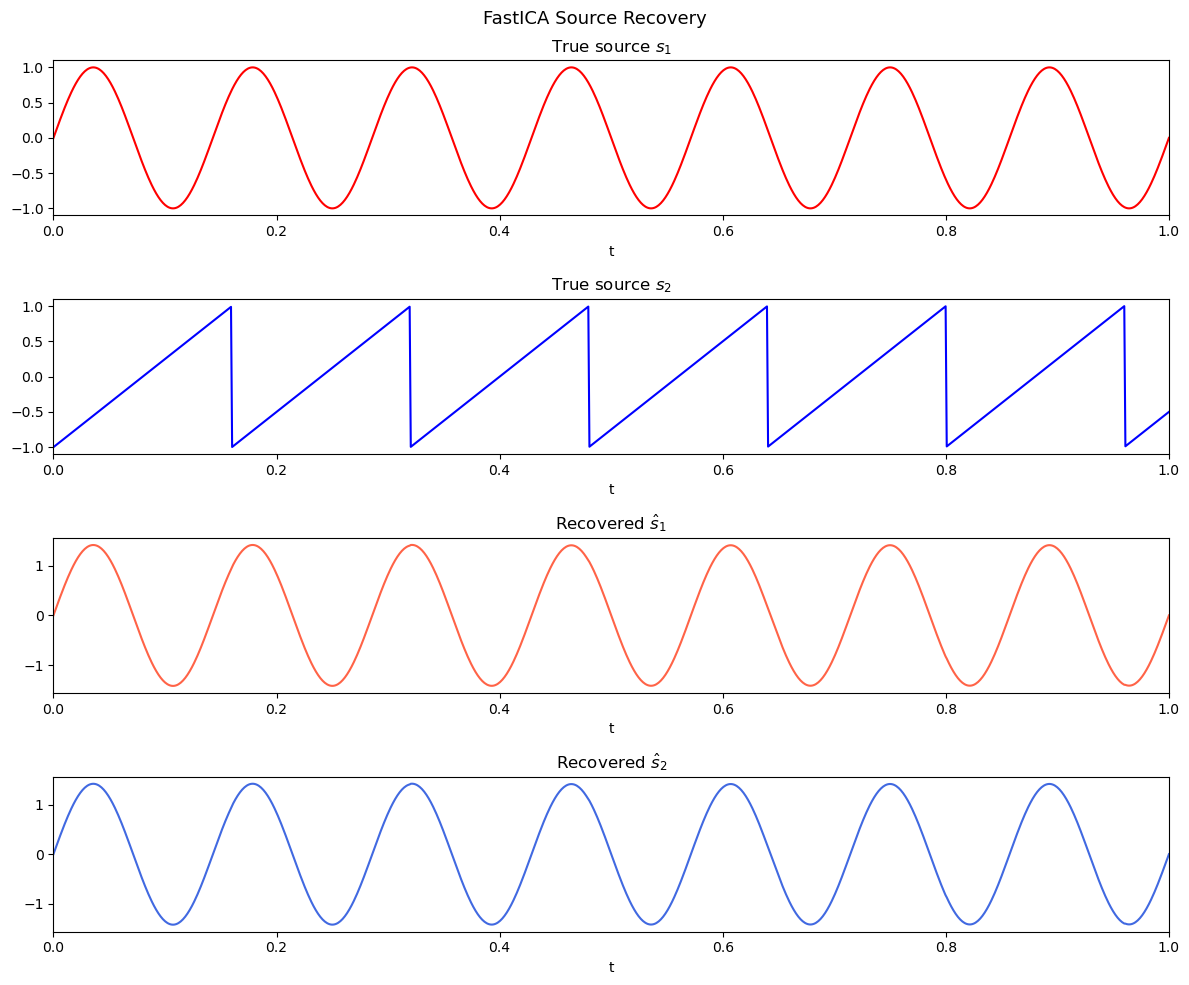

In [5]:
def fastica_1d(X_w, w_init=None, n_iter=200, rng=None):
    """Extract one IC from whitened data X_w using tanh contrast."""
    if rng is None: rng = np.random.default_rng(0)
    w = rng.standard_normal(X_w.shape[0])
    w = w / np.linalg.norm(w)
    for _ in range(n_iter):
        y = w @ X_w
        g  = np.tanh(y)
        gp = 1 - np.tanh(y)**2
        w_new = X_w @ g / X_w.shape[1] - gp.mean() * w
        w_new = w_new / np.linalg.norm(w_new)
        if abs(abs(w_new @ w) - 1) < 1e-8:
            break
        w = w_new
    return w

def fastica(X_w, n_comp=None, rng=None):
    """Full FastICA by deflation."""
    if rng is None: rng = np.random.default_rng(1)
    n = X_w.shape[0]
    if n_comp is None: n_comp = n
    W = []
    X_deflated = X_w.copy()
    for k in range(n_comp):
        w = fastica_1d(X_deflated, rng=rng)
        # Deflation: remove projection onto w
        X_deflated = X_deflated - np.outer(w, w @ X_deflated)
        W.append(w)
    return np.vstack(W)

rng_ica = np.random.default_rng(42)
W_ica = fastica(X_white, n_comp=2, rng=rng_ica)
S_recovered = W_ica @ X_white

# Align signs with original sources
for k in range(2):
    if np.corrcoef(S_recovered[k], S[k])[0,1] < 0:
        S_recovered[k] *= -1
    elif np.corrcoef(S_recovered[k], S[(k+1)%2])[0,1] < 0:
        S_recovered[k] *= -1

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
for ax, sig, title, c in zip(axes,
    [s1, s2, S_recovered[0], S_recovered[1]],
    ['True source $s_1$', 'True source $s_2$', 'Recovered $\\hat{s}_1$', 'Recovered $\\hat{s}_2$'],
    ['red','blue','tomato','royalblue']):
    ax.plot(t, sig, color=c, lw=1.5)
    ax.set_title(title); ax.set_xlabel('t'); ax.set_xlim(0,1)
plt.suptitle('FastICA Source Recovery', fontsize=13)
plt.tight_layout(); plt.savefig('ica_recovery.png', dpi=100, bbox_inches='tight'); plt.show()

### Interactive: varying the mixing angle

Rotate the mixing matrix by $\phi$ and see how the scatter plot changes.

In [ ]:
def show_mixing(phi_deg=45.0):
    phi_r = np.radians(phi_deg)
    A_r = np.array([[np.cos(phi_r), -np.sin(phi_r)],
                    [np.sin(phi_r),  np.cos(phi_r)]])
    X_r = A_r @ S
    X_w_r, _ = whiten(X_r)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].plot(s1, s2, 'k.', ms=2, alpha=0.5)
    axes[0].set_title('Sources'); axes[0].set_aspect('equal')
    axes[1].plot(X_r[0], X_r[1], 'b.', ms=2, alpha=0.5)
    axes[1].set_title(f'Mixture (φ={phi_deg:.0f}°)'); axes[1].set_aspect('equal')
    axes[2].plot(X_w_r[0], X_w_r[1], 'g.', ms=2, alpha=0.5)
    axes[2].set_title('Whitened'); axes[2].set_aspect('equal')
    plt.tight_layout(); plt.show()

interact(show_mixing, phi_deg=FloatSlider(min=0, max=180, step=5, value=45, description='φ (°)'));

### Snippet

In [6]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt
    fig, axes = _plt.subplots(2, 2, figsize=(9, 7))
    labels = ['Source 1 (sine)', 'Source 2 (sawtooth)', 'Recovered $\\hat{s}_1$', 'Recovered $\\hat{s}_2$']
    sigs = [s1, s2, S_recovered[0], S_recovered[1]]
    cols = ['red','blue','tomato','royalblue']
    for ax, sig, title, c in zip(axes.ravel(), sigs, labels, cols):
        ax.plot(t, sig, color=c, lw=1.5)
        ax.set_title(title); ax.set_xlim(0,1)
    fig.tight_layout()
    fig.savefig('snippet.png', dpi=150, bbox_inches='tight')

## Takeaways

- ICA solves the **blind source separation** problem by exploiting statistical independence and non-Gaussianity.
- **Whitening** reduces the problem to finding a rotation; FastICA finds the rotation by maximizing non-Gaussianity.
- The $\tanh$ contrast function is particularly robust and efficient in practice.
- Identifiability requires at most one Gaussian source (the **Darmois–Skitovitch theorem**).

## Bibliography

- A. Hyvärinen & E. Oja, *A Fast Fixed-Point Algorithm for Independent Component Analysis*, Neural Computation 9(7), 1997.
- A. Hyvärinen, J. Karhunen & E. Oja, *Independent Component Analysis*, Wiley, 2001.
- P. Comon, *Independent component analysis, a new concept?*, Signal Processing 36(3), 1994.